In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

sns.set(style="darkgrid")

## **Exploritary Data Analysis of Chicago Houses dataset**

### **step_01** load & cleaning & feature engineering

loading data

In [137]:
data = pd.read_csv('houses.csv')
data.head()
        

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


selecting data and renaming

In [184]:
db_columns = ['OverallQual', 'GrLivArea', '2ndFlrSF', 'GarageCars', 'YearBuilt', '1stFlrSF', 'TotRmsAbvGrd', 'BsmtFullBath', 'OverallCond', 'LotArea', 'Fireplaces','SalePrice']
data_cut = data[db_columns].copy()
data_cut.head()

,OverallQual,GrLivArea,2ndFlrSF,GarageCars,YearBuilt,1stFlrSF,TotRmsAbvGrd,BsmtFullBath,OverallCond,LotArea,Fireplaces,SalePrice
0,7,1710,854,2,2003,856,8,1,5,8450,0,208500
1,6,1262,0,2,1976,1262,6,0,8,9600,1,181500
2,7,1786,866,2,2001,920,6,1,5,11250,1,223500
3,7,1717,756,3,1915,961,7,1,5,9550,1,140000
4,8,2198,1053,3,2000,1145,9,1,5,14260,1,250000


In [185]:
print("Shape after selection:", data_cut.shape)

Shape after selection: (1460, 12)


In [186]:
column_mapping = {
    'OverallQual': 'overall_qmat',
    'GrLivArea': 'ground_sq',
    '2ndFlrSF': 'second_sq',
    'GarageCars': 'possible_cars_in_garage',
    'YearBuilt': 'year_built',
    '1stFlrSF': 'first_sq',
    'TotRmsAbvGrd': 'total_rooms',
    'BsmtFullBath': 'bas_bath_count',
    'OverallCond': 'overall_cond',
    'LotArea': 'overall_sq',
    'Fireplaces': 'fireplaces',
    'SalePrice': 'sale_price'
}

data_cut = data_cut[list(column_mapping.keys())].rename(columns=column_mapping)
data_cut.head()

,overall_qmat,ground_sq,second_sq,possible_cars_in_garage,year_built,first_sq,total_rooms,bas_bath_count,overall_cond,overall_sq,fireplaces,sale_price
0,7,1710,854,2,2003,856,8,1,5,8450,0,208500
1,6,1262,0,2,1976,1262,6,0,8,9600,1,181500
2,7,1786,866,2,2001,920,6,1,5,11250,1,223500
3,7,1717,756,3,1915,961,7,1,5,9550,1,140000
4,8,2198,1053,3,2000,1145,9,1,5,14260,1,250000


In [187]:
data_cut.describe()

,overall_qmat,ground_sq,second_sq,possible_cars_in_garage,year_built,first_sq,total_rooms,bas_bath_count,overall_cond,overall_sq,fireplaces,sale_price
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,346.992466,1.767123,1971.267808,1162.626712,6.517808,0.425342,5.575342,10516.828082,0.613014,180921.195890
std,1.382997,525.480383,436.528436,0.747315,30.202904,386.587738,1.625393,0.518911,1.112799,9981.264932,0.644666,79442.502883
min,1.000000,334.000000,0.000000,0.000000,1872.000000,334.000000,2.000000,0.000000,1.000000,1300.000000,0.000000,34900.000000
25%,5.000000,1129.500000,0.000000,1.000000,1954.000000,882.000000,5.000000,0.000000,5.000000,7553.500000,0.000000,129975.000000
50%,6.000000,1464.000000,0.000000,2.000000,1973.000000,1087.000000,6.000000,0.000000,5.000000,9478.500000,1.000000,163000.000000
75%,7.000000,1776.750000,728.000000,2.000000,2000.000000,1391.250000,7.000000,1.000000,6.000000,11601.500000,1.000000,214000.000000
max,10.000000,5642.000000,2065.000000,4.000000,2010.000000,4692.000000,14.000000,3.000000,9.000000,215245.000000,3.000000,755000.000000


#### **step 01.02** data cleaning

In [188]:
data_cut.isnull().sum()

overall_qmat               0
ground_sq                  0
second_sq                  0
possible_cars_in_garage    0
year_built                 0
first_sq                   0
total_rooms                0
bas_bath_count             0
overall_cond               0
overall_sq                 0
fireplaces                 0
sale_price                 0
dtype: int64

no nulls!

#### **step_01.03** feature engineering

In [189]:
# adding the age of the house feature (data is up to date 2010)
data_cut['house_age'] = 2010 - data_cut['year_built']

# adding total living area 
data_cut['total_living_area'] = data_cut['first_sq'] + data_cut['second_sq']

# adding mean area per room feature
data_cut['area_per_room'] = data_cut['total_living_area'] / data_cut['total_rooms']

### **step_02** target value distribution

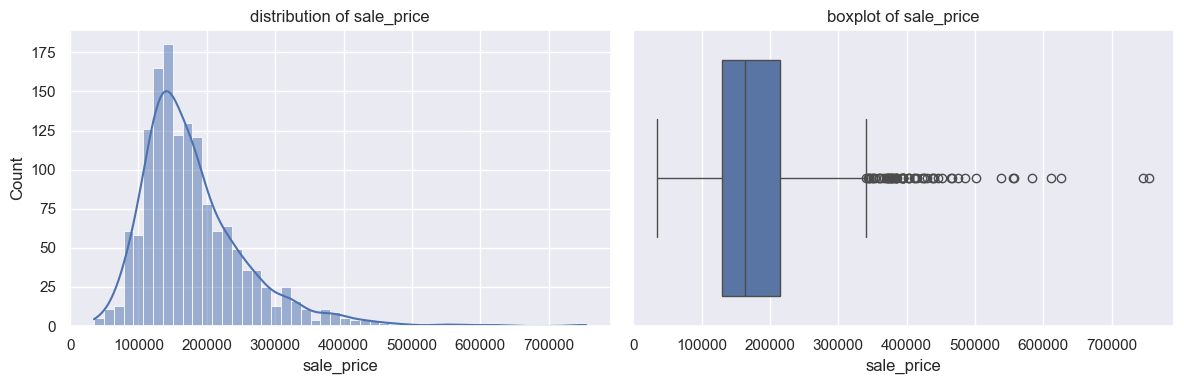

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: sale_price, dtype: float64


In [190]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

sns.histplot(data_cut['sale_price'], kde=True, bins=50)
plt.title('distribution of sale_price')

plt.subplot(1, 2, 2)
sns.boxplot(x=data_cut['sale_price'])
plt.title('boxplot of sale_price')

plt.tight_layout()
plt.show()

print(data_cut['sale_price'].describe())

It's obviously logariphmic, so let's see either all the continious features are the same?

### **step_02** features distribution & outliers & transformation & normalization

#### **step_02.1** features distribution

let's as well distribute all the features with the target

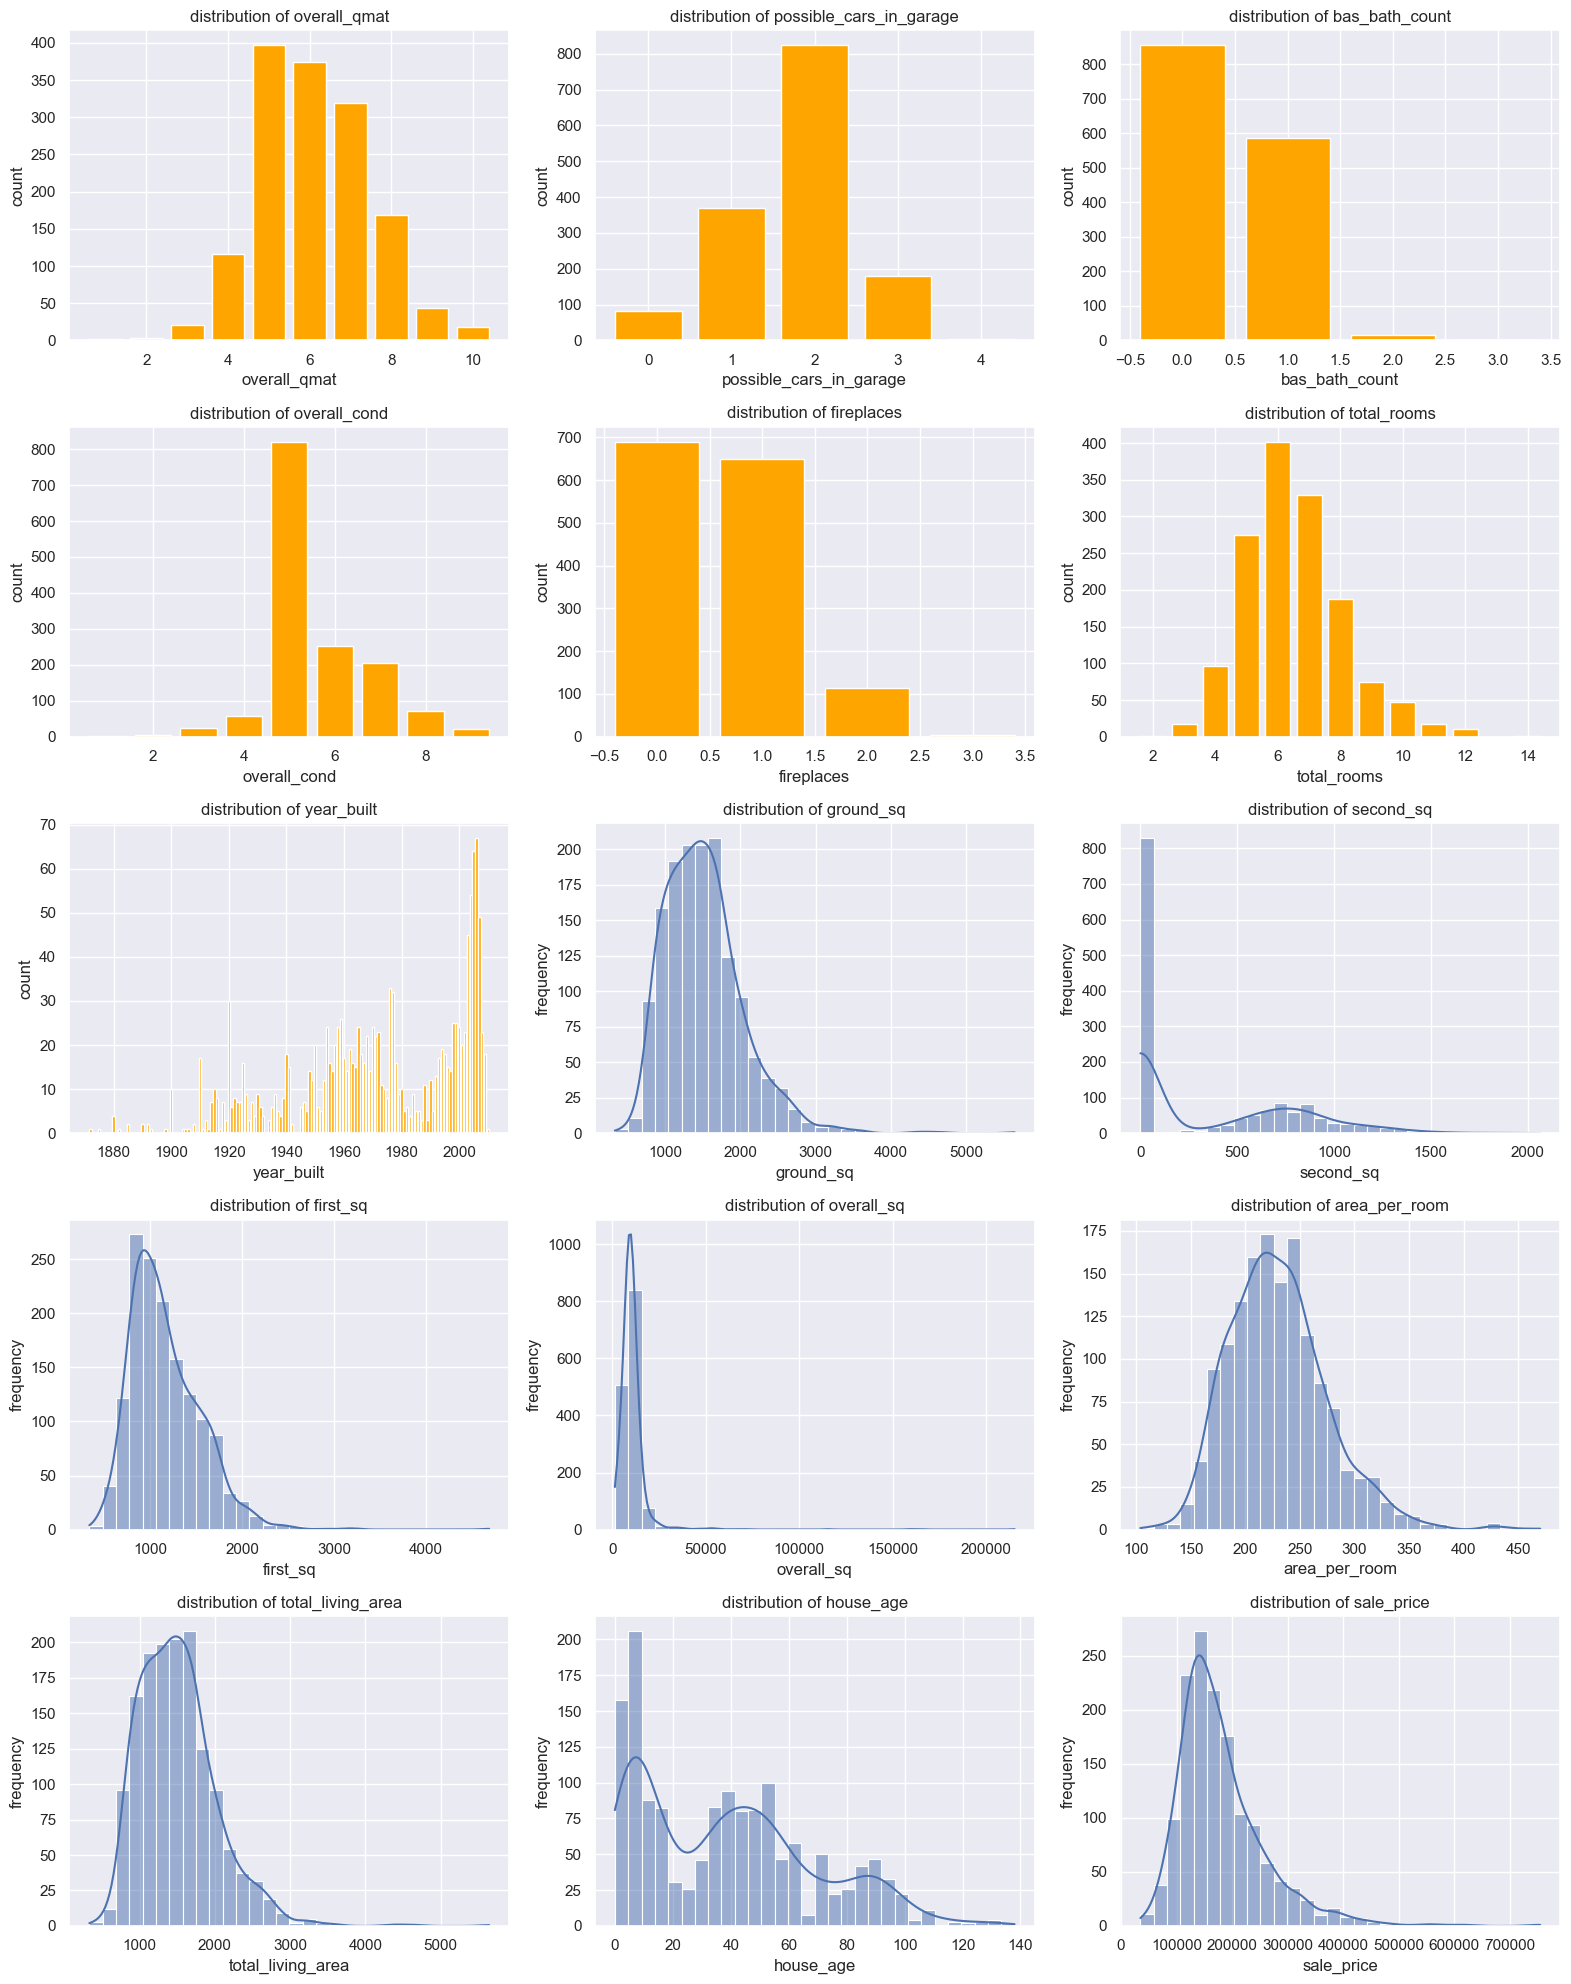

In [191]:
discrete_features = ['overall_qmat', 'possible_cars_in_garage', 'bas_bath_count', 'overall_cond', 'fireplaces', 'total_rooms', 'year_built']
continuous_features = ['ground_sq', 'second_sq', 'first_sq', 'overall_sq', 'area_per_room', 'total_living_area', 'house_age', 'sale_price']
all_features = discrete_features + continuous_features

# Plot
n_features = len(data_cut.columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))
for i in range(len(all_features)):
    col = all_features[i]
    plt.subplot(n_rows, n_cols, i + 1)
    if col in discrete_features:
        # Bar plot for discrete features
        value_counts = data_cut[col].value_counts().sort_index()
        plt.bar(value_counts.index, value_counts.values, color='orange')
        plt.xlabel(col)
        plt.ylabel('count')
    else:
        # Histogram for continuous features
        sns.histplot(data_cut[col], kde=True, bins=30)
        plt.xlabel(col)
        plt.ylabel('frequency')
    plt.title(f'distribution of {col}')

plt.tight_layout()
plt.show()

obviously all the **continious features** have **logarigmpic distribution**. let's normalize all of them and get rid of the outliers

#### **step_02.2** getting rid of the outliers & transformation & normalization

applying IQR

In [192]:
def remove_iqr_outliers(df, col, iqr_multiplier=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# applying IQR to key continuous features

print(f"befor IQR there're: {len(data_cut)} rows \n")

df_clean = data_cut.copy()
for col in continuous_features:
    df_clean = remove_iqr_outliers(df_clean, col, iqr_multiplier=1.5)
    print(f"after IQR on {col}: {len(df_clean)} rows")

befor IQR there're: 1460 rows 

after IQR on ground_sq: 1429 rows
after IQR on second_sq: 1429 rows
after IQR on first_sq: 1409 rows
after IQR on overall_sq: 1342 rows
after IQR on area_per_room: 1325 rows
after IQR on total_living_area: 1314 rows
after IQR on house_age: 1310 rows
after IQR on sale_price: 1247 rows


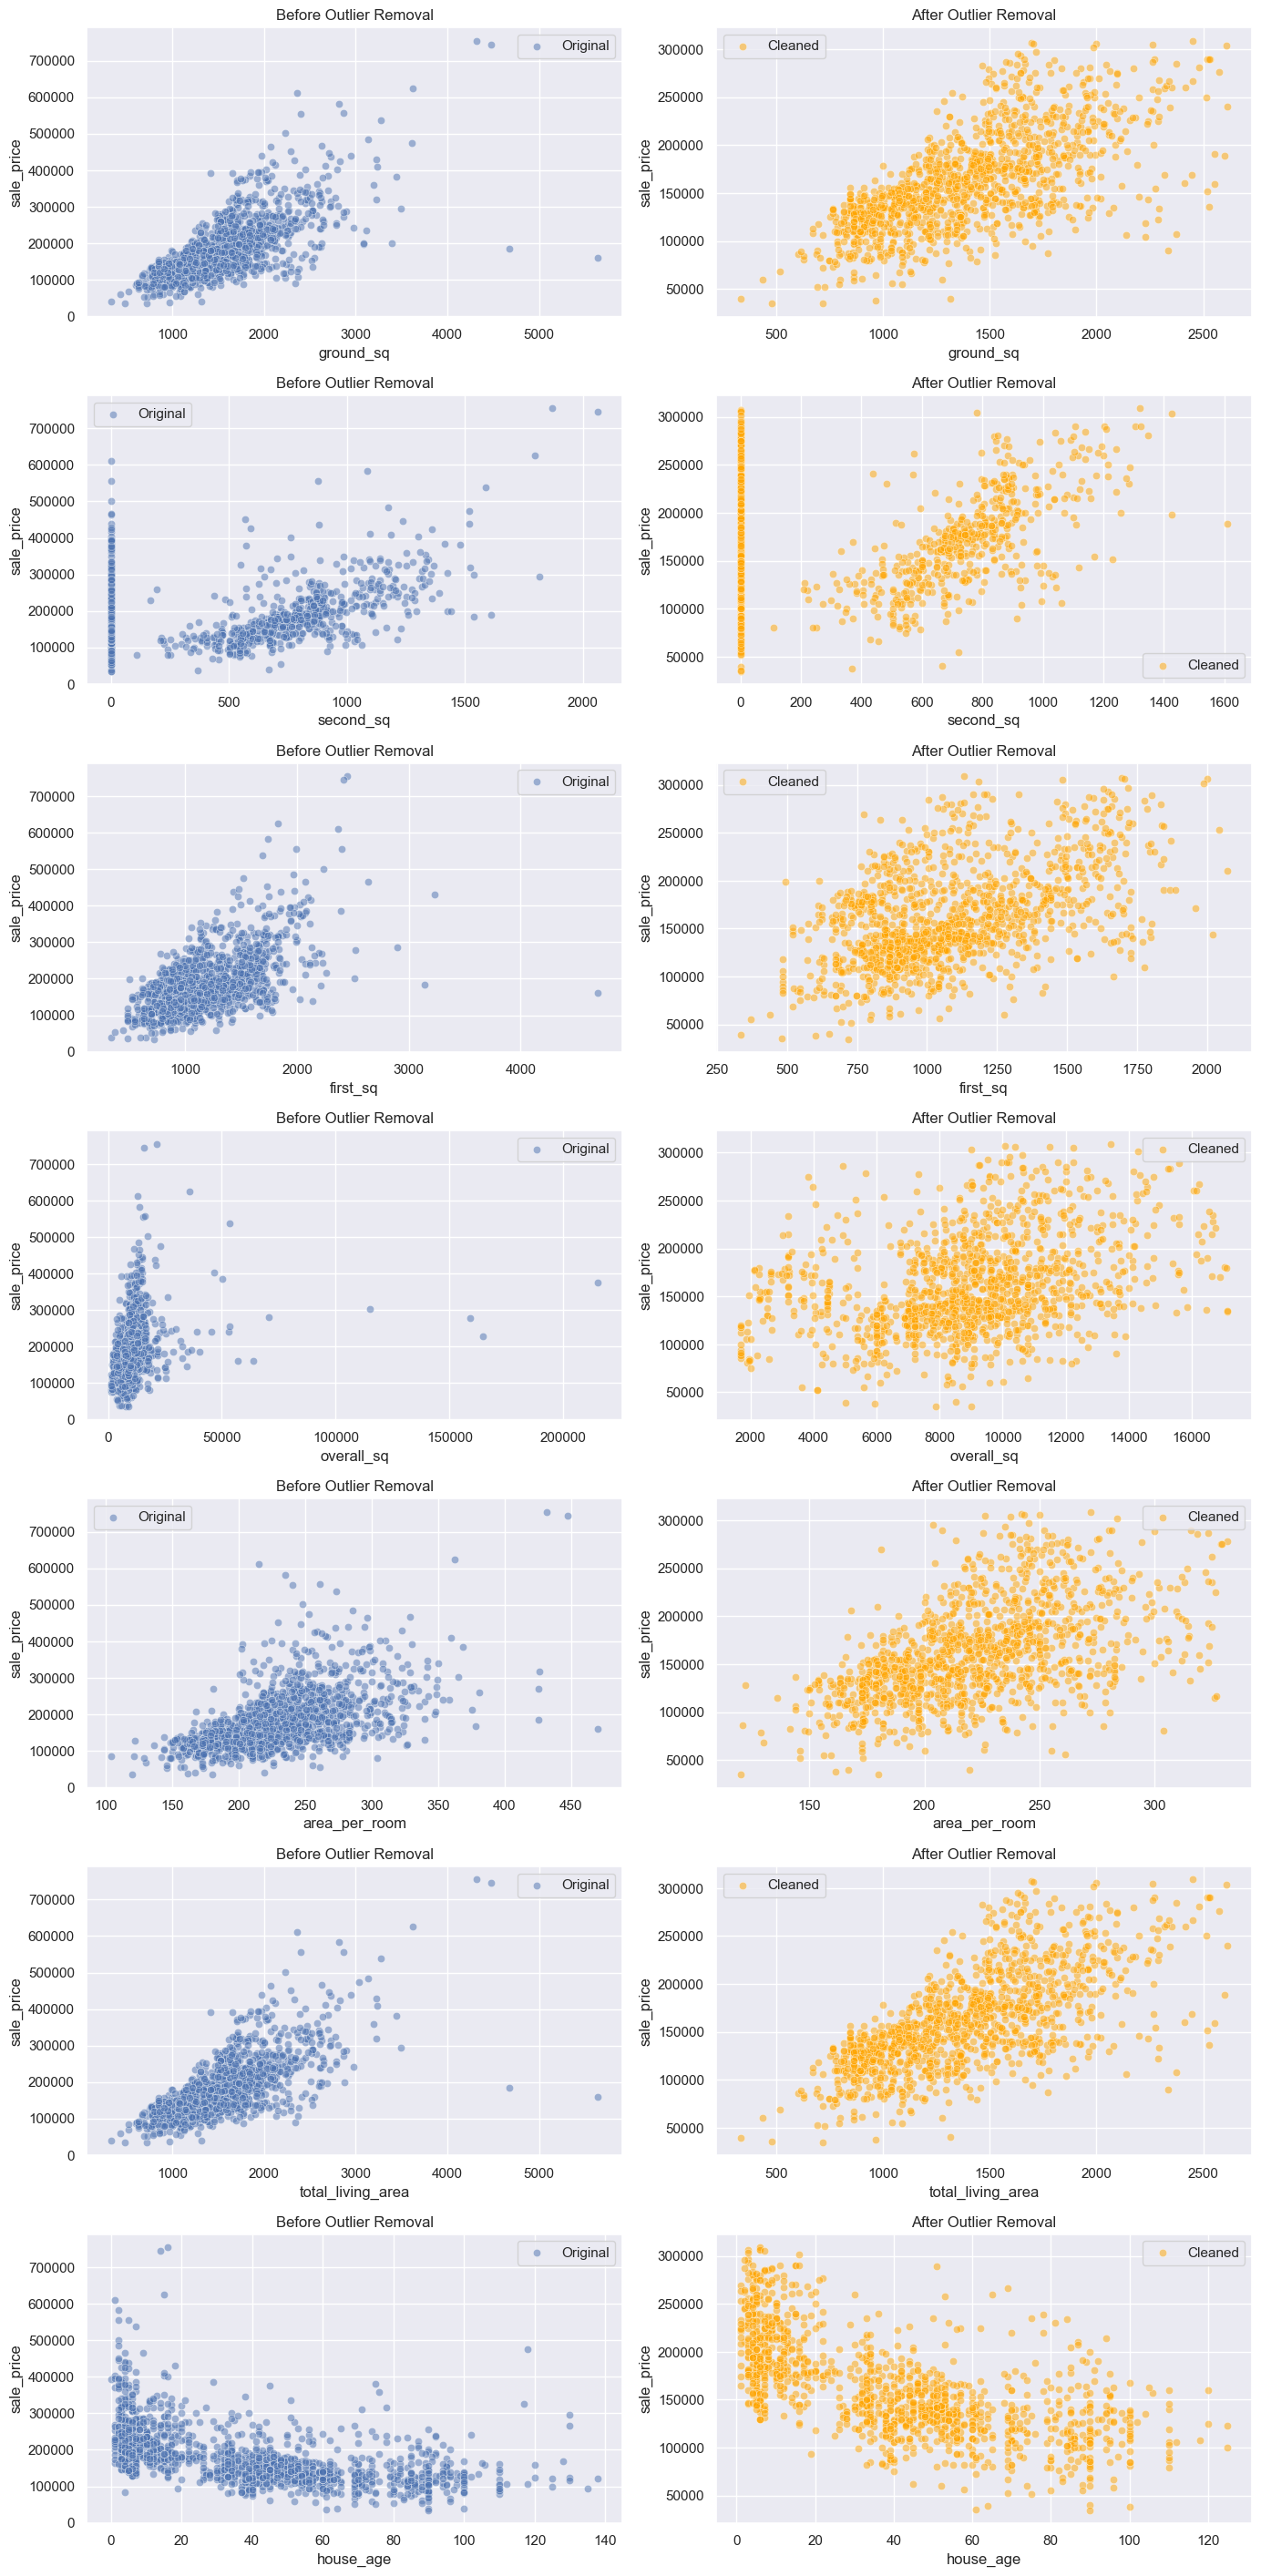

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, len(continuous_features) * 4))

j = 1
for i in range(len(continuous_features) - 1):
    col = continuous_features[i]
    plt.subplot(len(continuous_features), 2, j)
    sns.scatterplot(x=data_cut[col], y=data_cut['sale_price'], alpha=0.5, label='Original')
    plt.title('Before Outlier Removal')

    j += 1

    plt.subplot(len(continuous_features), 2, j)
    sns.scatterplot(x=df_clean[col], y=df_clean['sale_price'], alpha=0.5, color='orange', label='Cleaned')
    plt.title('After Outlier Removal')

    j += 1


plt.tight_layout()
plt.show()

moreover, it seems that mostly all the features have linear/polynomial dependance to the target value
  
let's transform & normalize all the rest continious features.

In [194]:
continuous_features.remove('sale_price')

df_trans = df_clean.copy()

for col in continuous_features:
    df_trans[col] = np.log1p(df_trans[col])

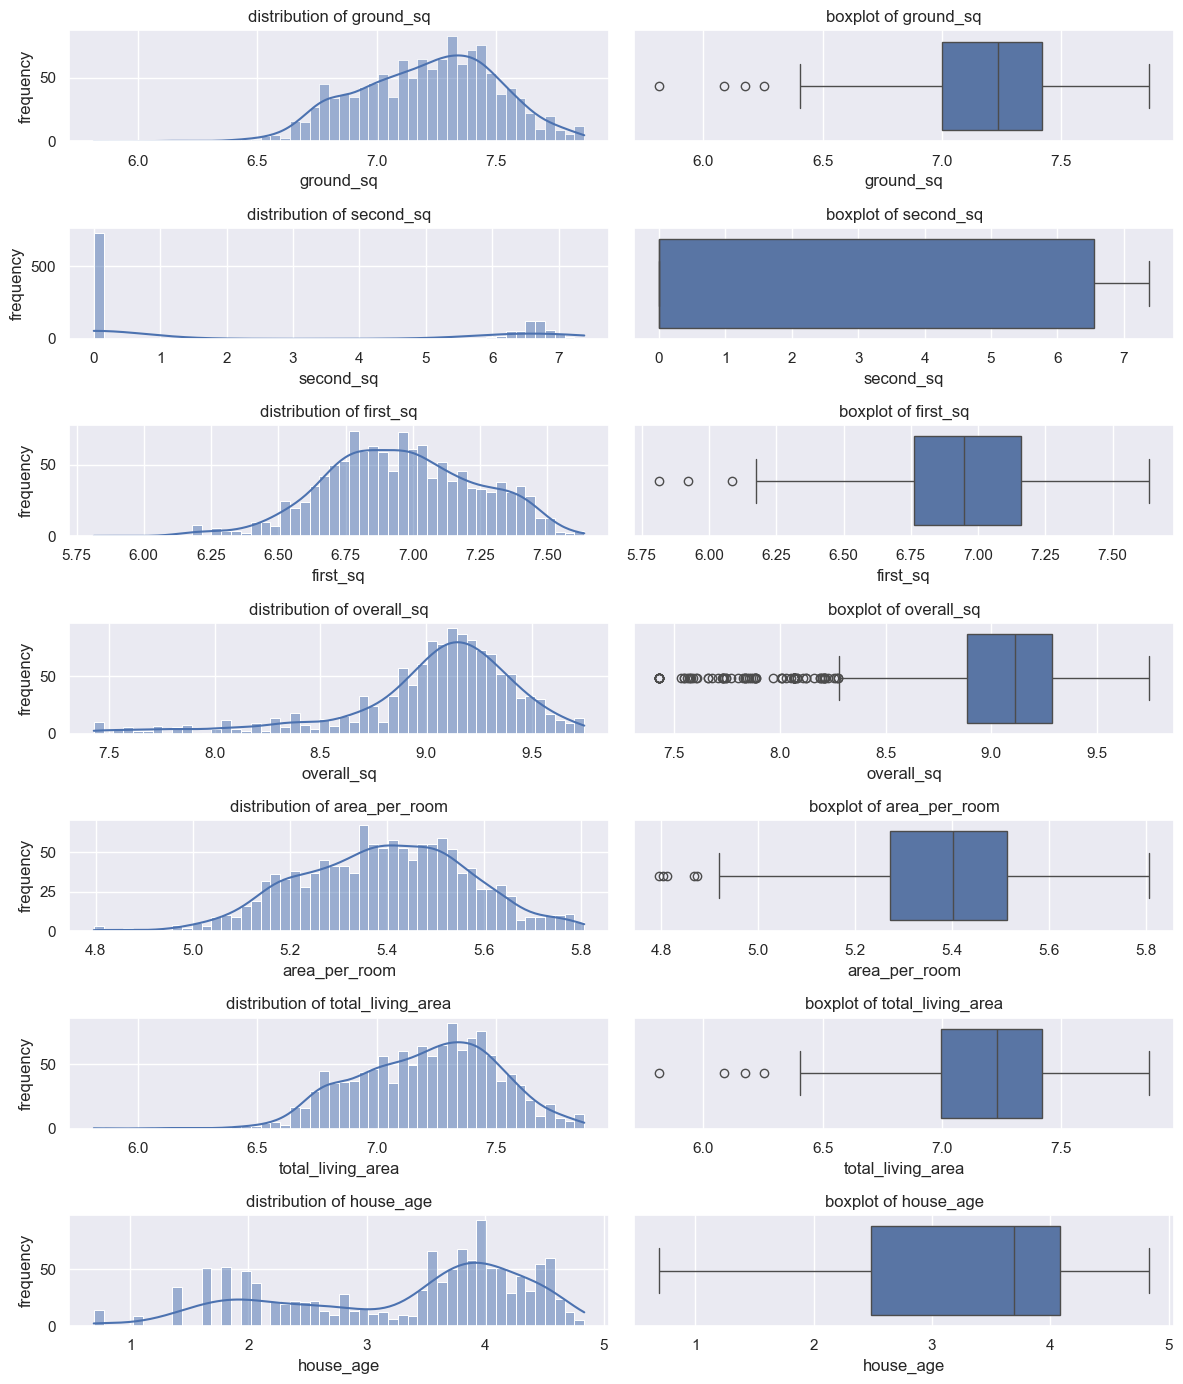

In [195]:
plt.figure(figsize=(12, len(continuous_features) * 2))

j = 1
rows = len(continuous_features)

for i in range(len(continuous_features)):

    col = continuous_features[i]

    plt.subplot(rows, 2, j)
    sns.histplot(df_trans[col], kde=True, bins=50)
    plt.ylabel('frequency')
    title_1 = 'distribution of ' + col
    plt.title(title_1)

    j += 1

    plt.subplot(rows, 2, j)
    sns.boxplot(x=df_trans[col])
    title_2 = 'boxplot of ' + col
    plt.title(title_2)

    plt.tight_layout()

    j += 1
    
plt.show()

In [198]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_trans.copy()
df_scaled[continuous_features] = scaler.fit_transform(df_clean[continuous_features])
df_scaled.overall_qmat = df_scaled.overall_qmat / 10
df_scaled.overall_cond = df_scaled.overall_cond / 10

In [199]:
df_scaled.head()

,overall_qmat,ground_sq,second_sq,possible_cars_in_garage,year_built,first_sq,total_rooms,bas_bath_count,overall_cond,overall_sq,fireplaces,sale_price,house_age,total_living_area,area_per_room
0,0.7,0.603509,0.530106,2,2003,0.300173,8,1,0.5,0.437904,0,208500,0.048387,0.603509,0.442635
1,0.6,0.407018,0.000000,2,1976,0.533640,6,0,0.8,0.512290,1,181500,0.266129,0.407018,0.426503
2,0.7,0.636842,0.537554,2,2001,0.336975,6,1,0.5,0.619017,1,223500,0.064516,0.636842,0.838842
3,0.7,0.606579,0.469274,3,1915,0.360552,7,1,0.5,0.509056,1,140000,0.758065,0.606579,0.591528
4,0.8,0.817544,0.653631,3,2000,0.466360,9,1,0.5,0.813713,1,250000,0.072581,0.817544,0.586507


let's look at the distribution one last time

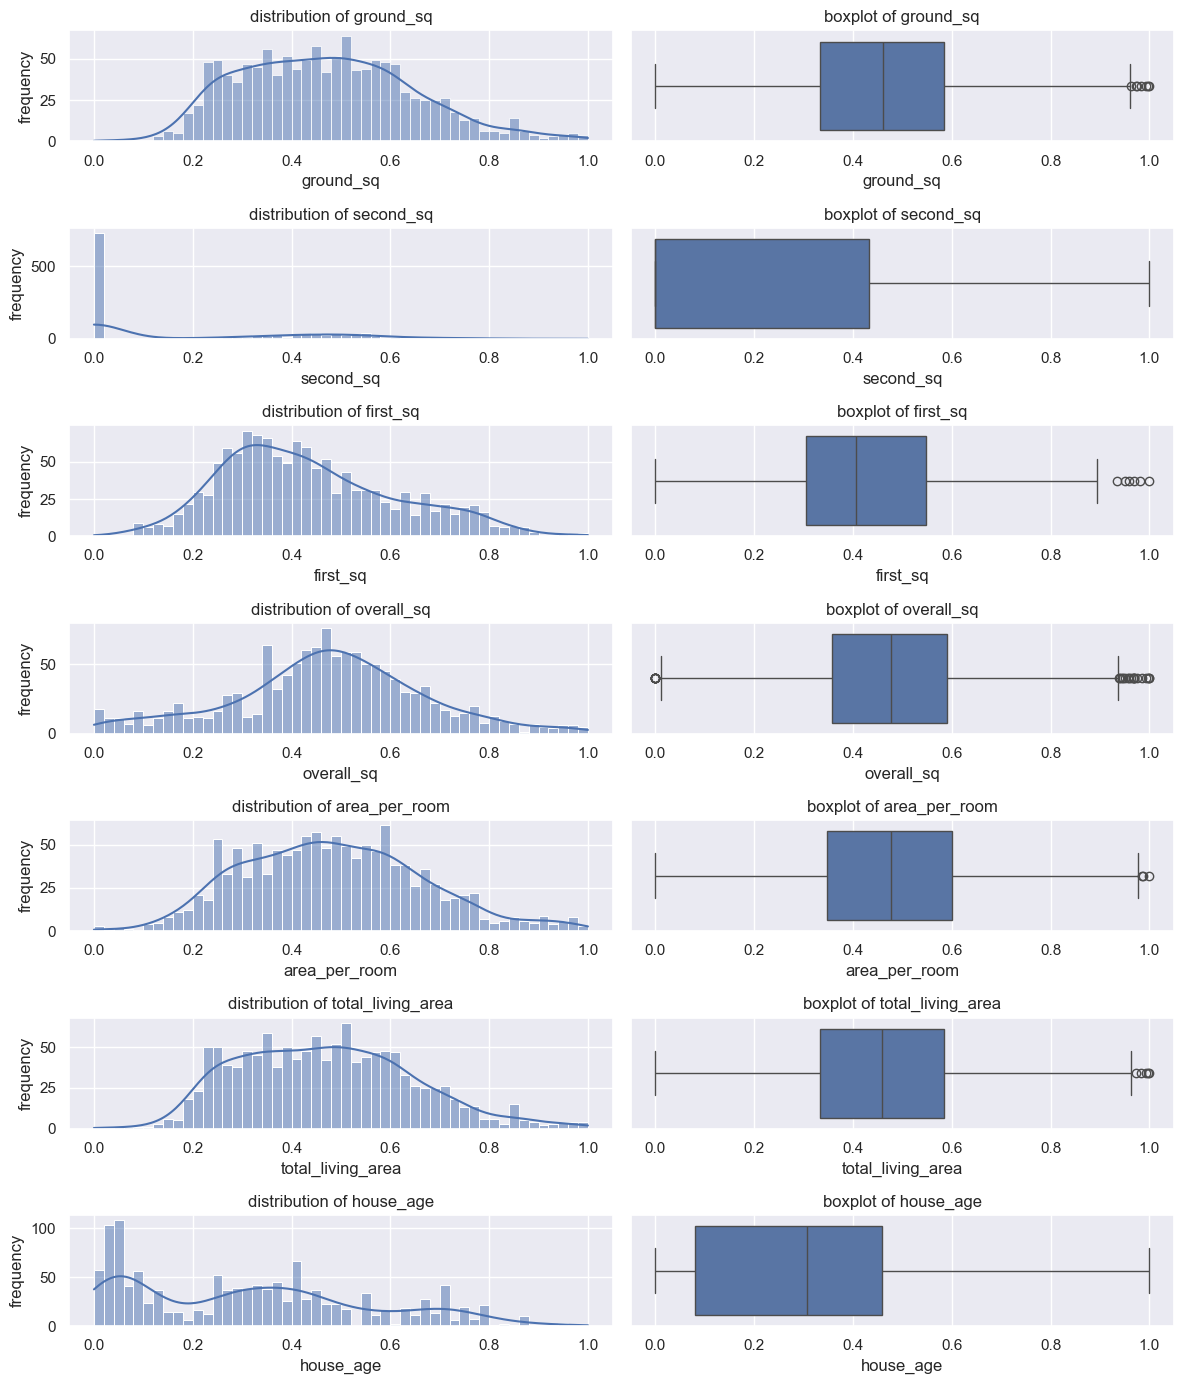

In [200]:
plt.figure(figsize=(12, len(continuous_features) * 2))

j = 1
rows = len(continuous_features)

for i in range(len(continuous_features)):

    col = continuous_features[i]

    plt.subplot(rows, 2, j)
    sns.histplot(df_scaled[col], kde=True, bins=50)
    plt.ylabel('frequency')
    title_1 = 'distribution of ' + col
    plt.title(title_1)

    j += 1

    plt.subplot(rows, 2, j)
    sns.boxplot(x=df_scaled[col])
    title_2 = 'boxplot of ' + col
    plt.title(title_2)

    plt.tight_layout()

    j += 1
    
plt.show()

saving min_max scaler for the future usage with input data

### **step_03** dumping dataset and scaler 

let's dump the final dataset and save the scaler to use it for the input values as well

In [203]:
df_scaled.to_csv('housing_for_db.csv', index=False)

In [202]:
import joblib
joblib.dump(scaler, 'housing_minmax_scaler.pkl')

['housing_minmax_scaler.pkl']

### **step_04** looking at the correlations

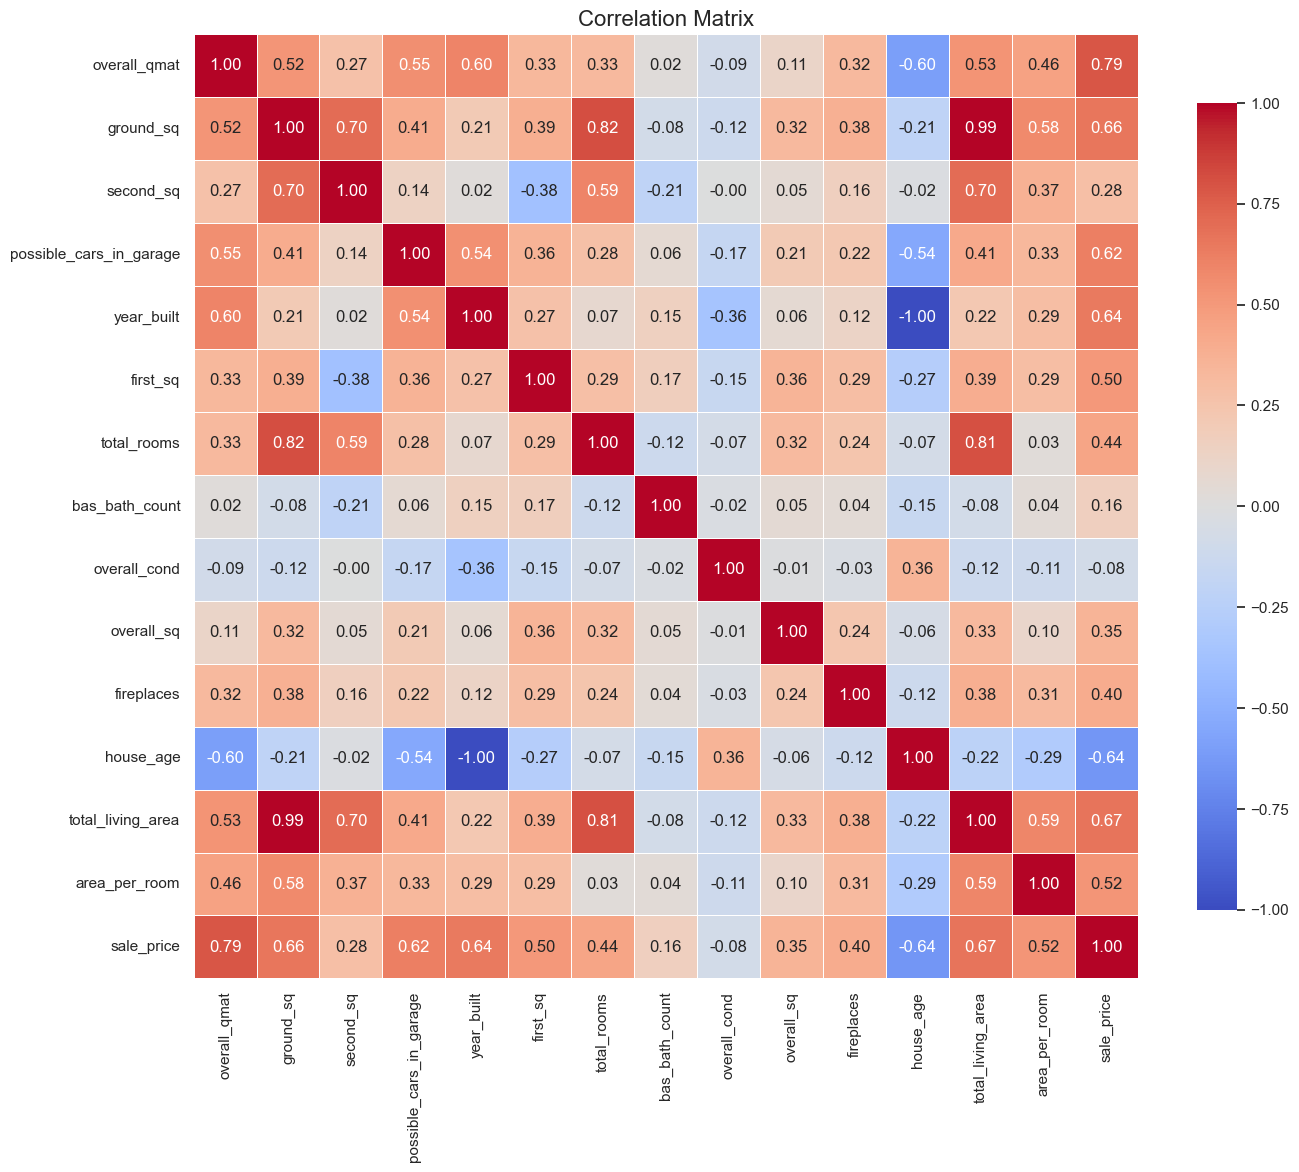

In [234]:
corows = list(df_scaled.columns)
corows.remove('sale_price')
corows.append('sale_price')

corr_df = df_scaled.copy()

corr_df = df_scaled[corows].corr()

plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

In [216]:
target_corr = corr_df['sale_price'].drop('sale_price').abs().sort_values(ascending=False)
print("top features by correlation with sale_price:")
print(target_corr.head(10))

top features by correlation with sale_price:
overall_qmat               0.787594
total_living_area          0.667488
ground_sq                  0.657761
year_built                 0.641081
house_age                  0.641081
possible_cars_in_garage    0.624295
area_per_room              0.522388
first_sq                   0.501571
total_rooms                0.444959
fireplaces                 0.399528
Name: sale_price, dtype: float64
